In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

columns = [
    'duration','protocol_type','service','flag','src_bytes',
    'dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell',
    'su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty_level'
]

df_train = pd.read_csv('../data/KDDTrain+.txt', names=columns)
df_test = pd.read_csv('../data/KDDTest+.txt', names=columns)
print(f'Training: {df_train.shape[0]:,} rows x {df_train.shape[1]} cols')
print(f'Test: {df_test.shape[0]:,} rows x {df_test.shape[1]} cols')
print('Dataset loaded!')

Training: 125,973 rows x 43 cols
Test: 22,544 rows x 43 cols
Dataset loaded!


In [2]:
print('=== First 5 Rows ===')
df_train.head()

=== First 5 Rows ===


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [3]:
attack_mapping = {
    'normal': 'Normal',
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS',
    'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe',
    'portsweep': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L',
    'multihop': 'R2L', 'phf': 'R2L', 'spy': 'R2L',
    'warezclient': 'R2L', 'warezmaster': 'R2L',
    'snmpgetattack': 'R2L', 'named': 'R2L', 'xlock': 'R2L',
    'xsnoop': 'R2L', 'sendmail': 'R2L', 'httptunnel': 'R2L',
    'worm': 'R2L', 'snmpguess': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'rootkit': 'U2R', 'xterm': 'U2R', 'ps': 'U2R', 'sqlattack': 'U2R'
}

df_train['attack_category'] = df_train['label'].map(attack_mapping)
df_train['is_attack'] = (df_train['attack_category'] != 'Normal').astype(int)

print('=== Attack Categories ===')
print(df_train['attack_category'].value_counts())
print(f'\nNormal: {(df_train["is_attack"]==0).sum():,}')
print(f'Attack: {(df_train["is_attack"]==1).sum():,}')

=== Attack Categories ===
attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Normal: 67,343
Attack: 58,630


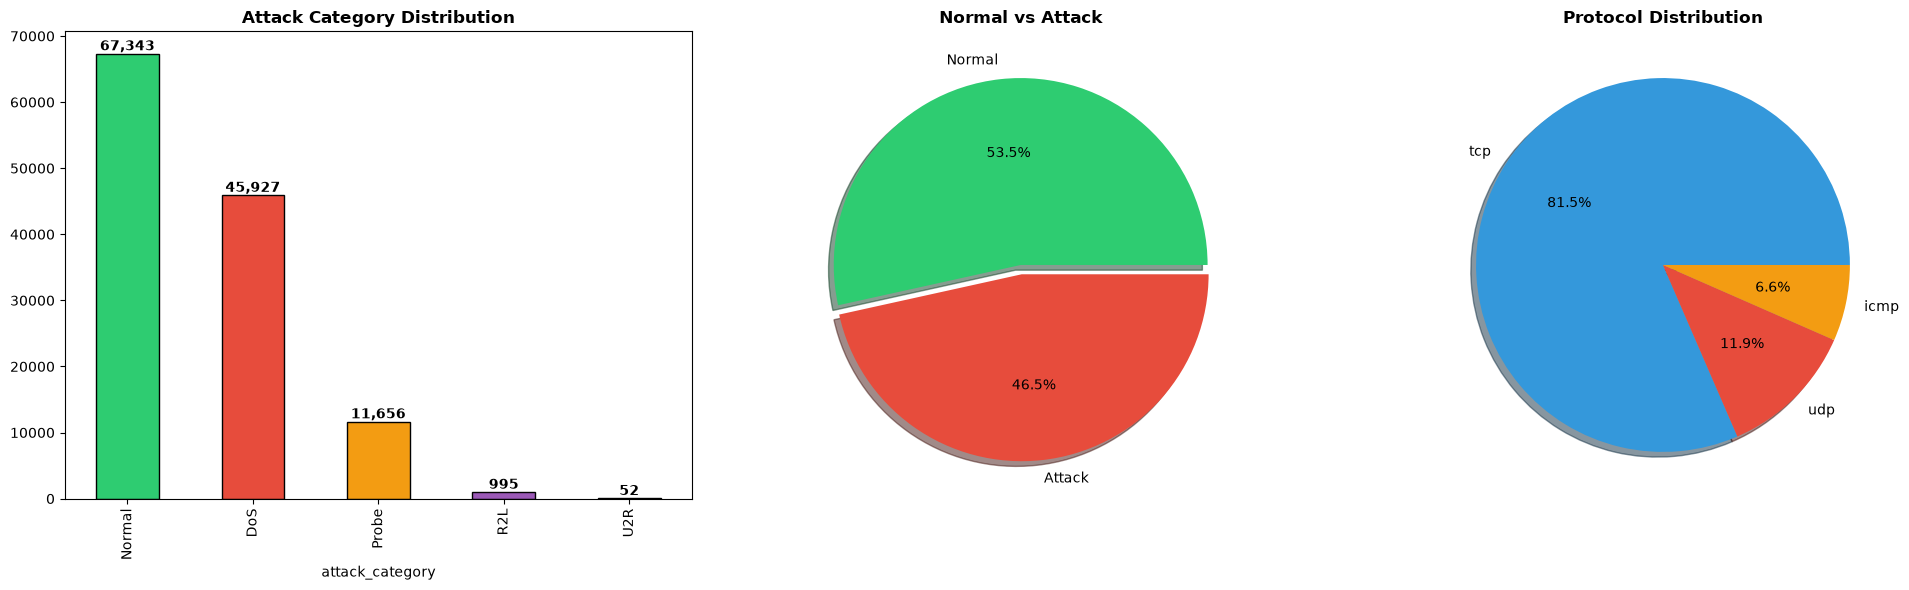

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#3498db']
cats = df_train['attack_category'].value_counts()
cats.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Attack Category Distribution', fontweight='bold')
for i, (idx, val) in enumerate(cats.items()):
    axes[0].text(i, val+500, f'{val:,}', ha='center', fontweight='bold')

atk = df_train['is_attack'].value_counts()
axes[1].pie(atk, labels=['Normal','Attack'], autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], explode=[0,0.05], shadow=True)
axes[1].set_title('Normal vs Attack', fontweight='bold')

proto = df_train['protocol_type'].value_counts()
axes[2].pie(proto, labels=proto.index, autopct='%1.1f%%',
            colors=['#3498db','#e74c3c','#f39c12'], shadow=True)
axes[2].set_title('Protocol Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

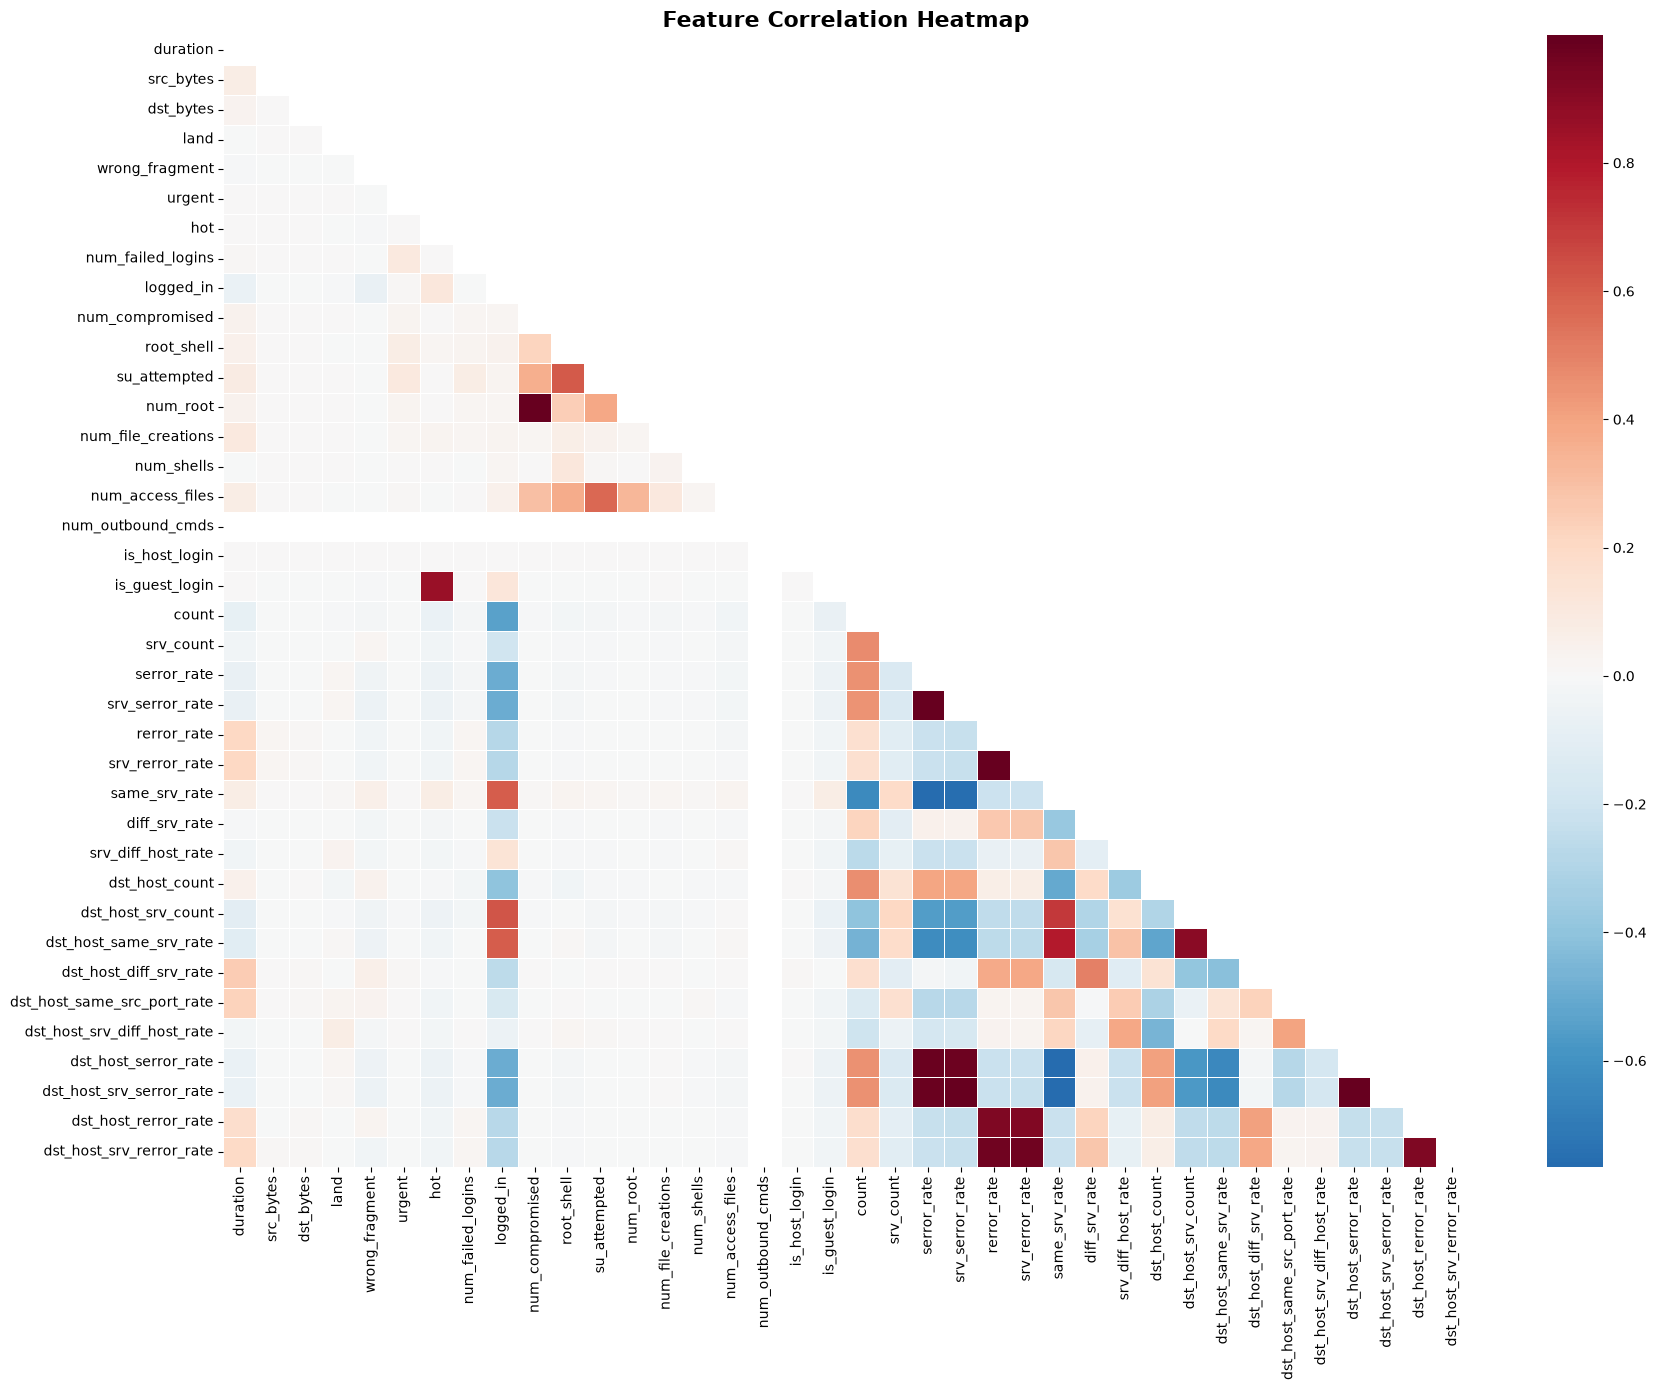

In [5]:
num_cols = df_train.select_dtypes(include=['number']).columns.tolist()
num_cols = [c for c in num_cols if c not in ['difficulty_level', 'is_attack']]
corr = df_train[num_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

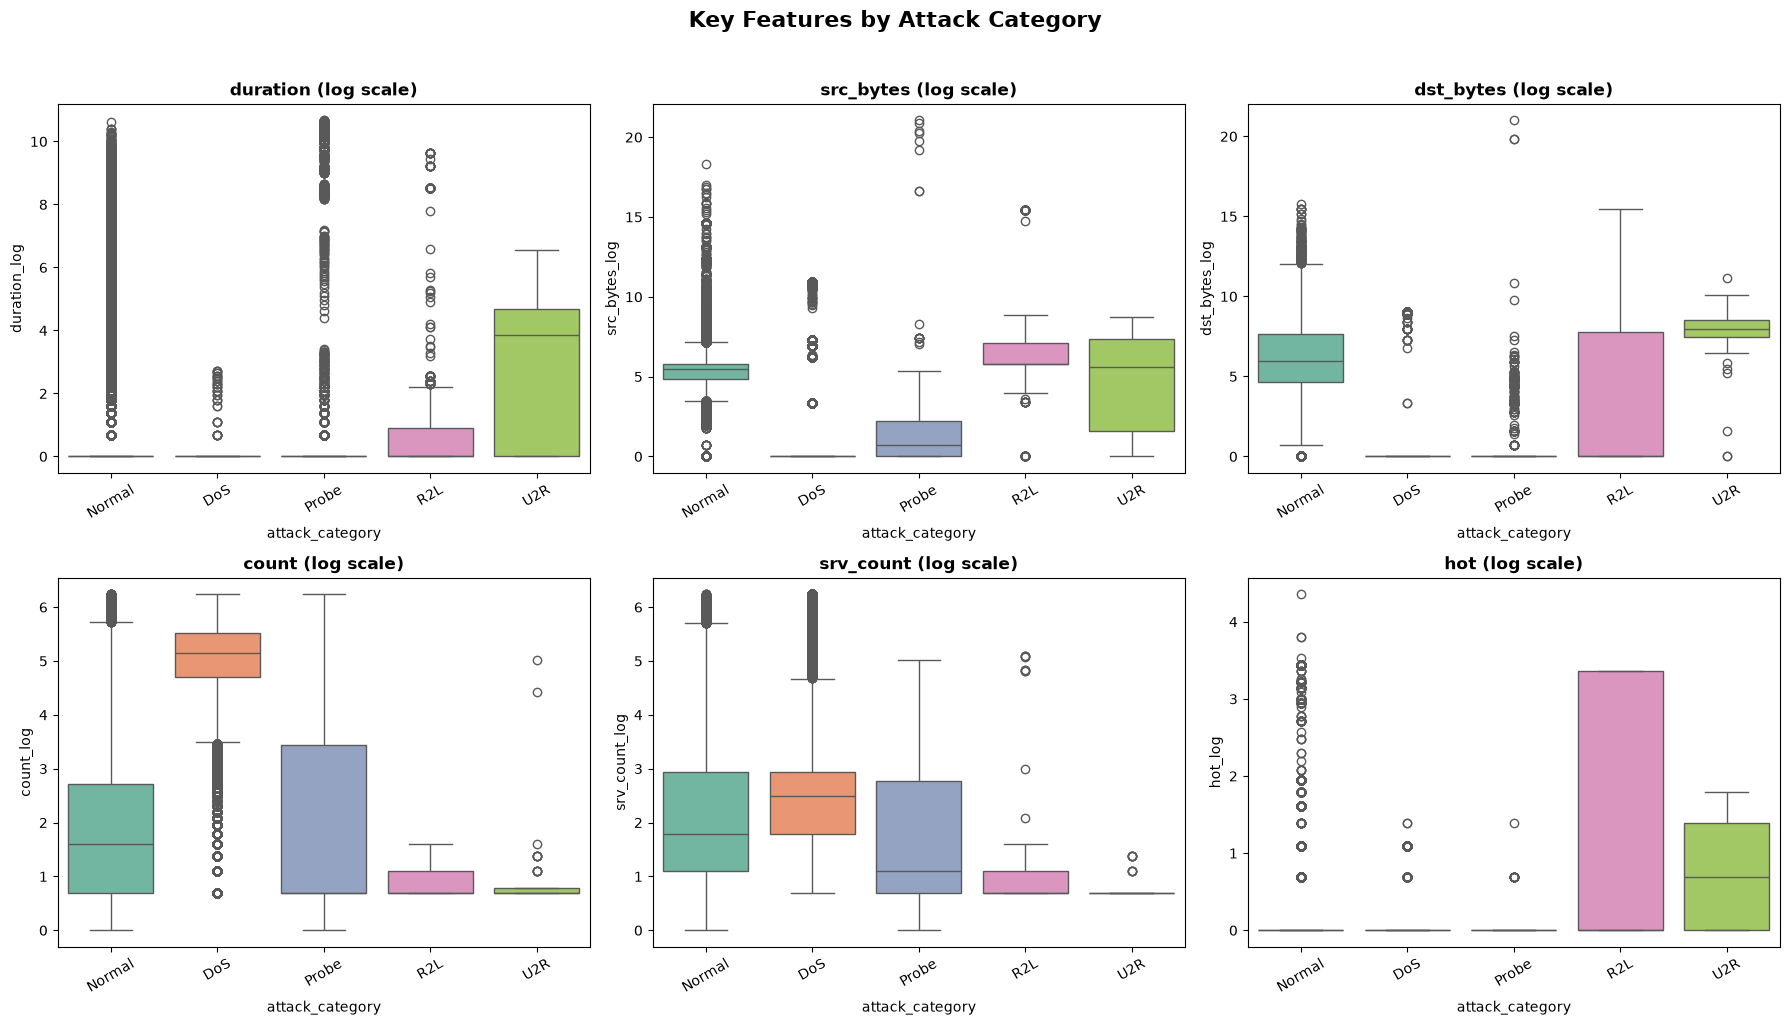

In [6]:
key_features = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'hot']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    data = df_train.copy()
    data[f'{feature}_log'] = np.log1p(data[feature])
    sns.boxplot(data=data, x='attack_category', y=f'{feature}_log', ax=axes[i],
                palette='Set2', order=['Normal', 'DoS', 'Probe', 'R2L', 'U2R'])
    axes[i].set_title(f'{feature} (log scale)', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Key Features by Attack Category', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
for cat in ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']:
    s = df_train[df_train['attack_category'] == cat]
    print(f'\n--- {cat} ({len(s):,} records) ---')
    print(f'  Avg Duration:   {s["duration"].mean():.2f} sec')
    print(f'  Avg Src Bytes:  {s["src_bytes"].mean():,.0f}')
    print(f'  Avg Dst Bytes:  {s["dst_bytes"].mean():,.0f}')
    print(f'  Avg Error Rate: {s["serror_rate"].mean():.3f}')
    print(f'  Top Service:    {s["service"].mode()[0]}')
    print(f'  Top Protocol:   {s["protocol_type"].mode()[0]}')
    print(f'  Top Flag:       {s["flag"].mode()[0]}')


--- Normal (67,343 records) ---
  Avg Duration:   168.59 sec
  Avg Src Bytes:  13,133
  Avg Dst Bytes:  4,330
  Avg Error Rate: 0.013
  Top Service:    http
  Top Protocol:   tcp
  Top Flag:       SF

--- DoS (45,927 records) ---
  Avg Duration:   0.01 sec
  Avg Src Bytes:  1,176
  Avg Dst Bytes:  169
  Avg Error Rate: 0.748
  Top Service:    private
  Top Protocol:   tcp
  Top Flag:       S0

--- Probe (11,656 records) ---
  Avg Duration:   2074.86 sec
  Avg Src Bytes:  385,680
  Avg Dst Bytes:  181,075
  Avg Error Rate: 0.047
  Top Service:    private
  Top Protocol:   tcp
  Top Flag:       SF

--- R2L (995 records) ---
  Avg Duration:   633.42 sec
  Avg Src Bytes:  307,727
  Avg Dst Bytes:  81,822
  Avg Error Rate: 0.012
  Top Service:    ftp_data
  Top Protocol:   tcp
  Top Flag:       SF

--- U2R (52 records) ---
  Avg Duration:   80.94 sec
  Avg Src Bytes:  906
  Avg Dst Bytes:  5,142
  Avg Error Rate: 0.038
  Top Service:    telnet
  Top Protocol:   tcp
  Top Flag:       SF


In [8]:
df_test['attack_category'] = df_test['label'].map(attack_mapping)
df_train.to_csv('../data/train_processed.csv', index=False)
df_test.to_csv('../data/test_processed.csv', index=False)
print('✅ Processed data saved!')
print('🎉 EDA Complete! Next: Feature Engineering & Modeling')

✅ Processed data saved!
🎉 EDA Complete! Next: Feature Engineering & Modeling
